# Install Dependencies

In [ ]:
# Install the libraries we need for fine-tuning and evaluation
! pip install -U transformers accelerate datasets bertviz umap-learn seaborn scikit-learn evaluate

# Load & Examine Data

In [2]:
# Import pandas for data loading and basic analysis
import pandas as pd

# Load the dataset from GitHub
df = pd.read_csv("https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/twitter_multi_class_sentiment.csv")

In [3]:
# Show the first 5 rows
# This helps us quickly understand the data structure
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [4]:
# Check the dataset information
# We can see the number of rows, column names, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        16000 non-null  object
 1   label       16000 non-null  int64 
 2   label_name  16000 non-null  object
dtypes: int64(1), object(2)
memory usage: 375.1+ KB


In [5]:
# Check for missing values in each column
# Here we confirm whether the dataset has null values
df.isnull().sum()

,0
text,0
label,0
label_name,0


In [6]:
# Show basic statistics of the dataset
# This is mainly useful for numerical columns
df.describe()

,label
count,16000.000000
mean,1.565937
std,1.501430
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,5.000000


In [7]:
# Count how many samples belong to each sentiment class
# This helps us check whether the classes are balanced
df["label_name"].value_counts()

,count
label_name,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


# Data Anlaysis

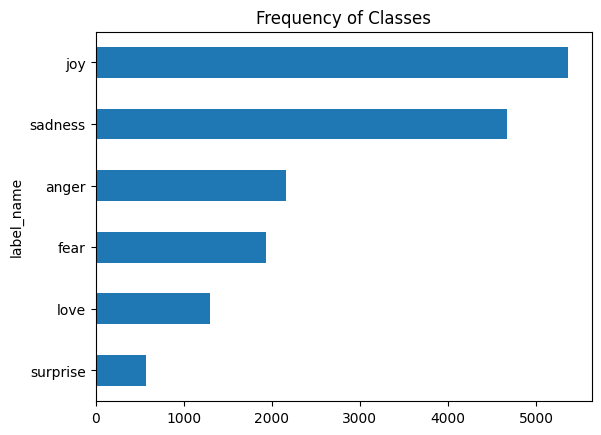

In [8]:
import matplotlib.pyplot as plt

# Count the number of samples in each class
# ascending=True makes the bar chart easier to read from low to high
label_counts = df["label_name"].value_counts(ascending=True)

# Plot a horizontal bar chart
label_counts.plot.barh()

# Add a title to the chart
plt.title("Frequency of Classes")

# Show the plot
plt.show()

<Axes: title={'center': 'words_per_tweet'}, xlabel='label_name'>

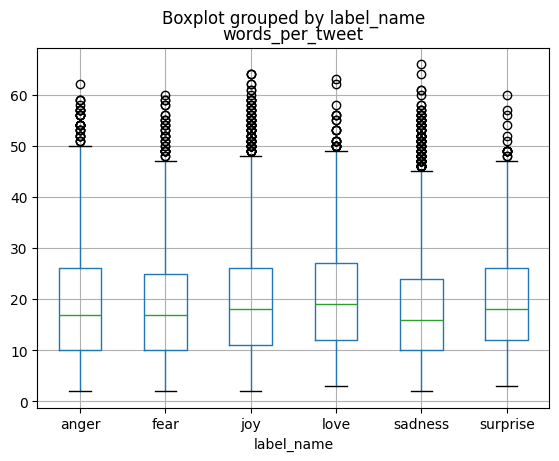

In [9]:
# Create a new column for the number of words in each tweet
# We split the text into words and count them
df["words_per_tweet"] = df["text"].str.split().apply(len)

# Draw a boxplot to compare tweet length across sentiment labels
df.boxplot("words_per_tweet", by="label_name")

# Observation:
# Tweets with the "sadness" label seem to have fewer words on average
# than tweets with the "love" label.

# Text to Tokens Conversion  
Hugging Face: [Auto Classes](https://huggingface.co/docs/transformers/en/model_doc/auto)

In [10]:
# Transformers cannot work directly with raw text
# The text must first be tokenized and converted into numbers
from transformers import AutoTokenizer

# Choose a pretrained tokenizer checkpoint
model_ckpt = "bert-base-uncased"

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [11]:
# Example input text
text = "I love machine learning! Tokenization is awesome!"

# Tokenize the text
# The tokenizer returns input IDs and attention mask
encoded_text = tokenizer(text)
encoded_text

{'input_ids': [101, 1045, 2293, 3698, 4083, 999, 19204, 3989, 2003, 12476, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [12]:
# Print basic tokenizer information
# vocab_size = number of tokens in the vocabulary
# model_max_length = maximum input length supported by the model
print(tokenizer.vocab_size, tokenizer.model_max_length)

30522 512


In [13]:
# Show the tokenizer vocabulary
# This is a dictionary that maps tokens to IDs
tokenizer.vocab

{'tendency': 11765,
 'yielded': 17544,
 'obvious': 5793,
 '奈': 1814,
 'lowering': 13845,
 'marijuana': 16204,
 'supper': 15264,
 'cartridges': 22998,
 'nevada': 7756,
 '##ita': 6590,
 'leukemia': 25468,
 'mandatory': 10915,
 '##belle': 25766,
 'standardization': 28648,
 'francois': 8173,
 'morrow': 19084,
 'undertaking': 18457,
 '##sack': 25607,
 'nod': 7293,
 '[unused310]': 315,
 'abuse': 6905,
 'dusk': 18406,
 '##iction': 28097,
 'lee': 3389,
 '##ᅮ': 30014,
 '[unused957]': 962,
 '##bic': 13592,
 '##minating': 27932,
 'euclidean': 25826,
 '##pha': 21890,
 'priorities': 18402,
 'convicts': 24948,
 'maia': 23478,
 '1807': 13206,
 'trends': 12878,
 'discrimination': 9147,
 'sighting': 29426,
 'luton': 17807,
 'than': 2084,
 'crowe': 25657,
 'implicit': 24655,
 'thoroughly': 12246,
 'develops': 11791,
 'dominique': 18165,
 'paused': 5864,
 '##pala': 19636,
 'stimulation': 20858,
 'padua': 24941,
 '##utz': 20267,
 '##achal': 24409,
 'arrays': 27448,
 '##佐': 30290,
 '##lage': 20679,
 '`': 1

# Data Loader and Train Test Split

In [14]:
# Show the first few rows again
df.head()

,text,label,label_name,words_per_tweet
0,i didnt feel humiliated,0,sadness,4
1,i can go from feeling so hopeless to so damned...,0,sadness,21
2,im grabbing a minute to post i feel greedy wrong,3,anger,10
3,i am ever feeling nostalgic about the fireplac...,2,love,18
4,i am feeling grouchy,3,anger,4


In [15]:
from sklearn.model_selection import train_test_split

# Split the data into training and temporary test sets
# stratify=df["label_name"] keeps the label distribution balanced
train, test = train_test_split(df, test_size=0.3, stratify=df["label_name"])

# Split the temporary test set into test and validation sets
# Here, 1/3 of the 30% becomes validation, so:
# train = 70%, test = 20%, validation = 10%
test, validation = train_test_split(test, test_size=1/3, stratify=test["label_name"])

# Check the size of each split
train.shape, test.shape, validation.shape

((11200, 4), (3200, 4), (1600, 4))

In [16]:
from datasets import Dataset, DatasetDict

# Convert pandas DataFrames into Hugging Face Datasets
# preserve_index=False avoids adding the pandas index as a column
dataset = DatasetDict(
    {'train':Dataset.from_pandas(train, preserve_index=False),
     'test': Dataset.from_pandas(test, preserve_index=False),
     'validation': Dataset.from_pandas(validation, preserve_index=False)}
)

# Display the dataset dictionary
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet'],
        num_rows: 11200
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet'],
        num_rows: 3200
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet'],
        num_rows: 1600
    })
})

# Tokenization of the Emotion/Sentiment Data

In [17]:
# Show the first example in the training set
dataset['train'][0]

{'text': 'i sometimes feel hated but i am not it is all in my head',
 'label': 3,
 'label_name': 'anger',
 'words_per_tweet': 14}

In [18]:
# Define a tokenization function
# It converts raw text into model inputs
def tokenize(batch):
  temp = tokenizer(batch['text'], padding=True, truncation=True)
  return temp

# Test the tokenizer on one example
print(tokenize(dataset['train'][0]))

{'input_ids': [101, 1045, 2823, 2514, 6283, 2021, 1045, 2572, 2025, 2009, 2003, 2035, 1999, 2026, 2132, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [19]:
# Look at two examples together
# When padding=True, the shorter text is padded with 0s
# in input_ids so that both sequences have the same length
# The attention_mask is 1 for real tokens and 0 for padding tokens
for items, values in tokenize(dataset['train'][:2]).items():
  print(items, ":\n")
  for value in values:
    print(value)
  print('\n')

input_ids :

[101, 1045, 2823, 2514, 6283, 2021, 1045, 2572, 2025, 2009, 2003, 2035, 1999, 2026, 2132, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[101, 1045, 5457, 2026, 5346, 2007, 1996, 3606, 2138, 1045, 4669, 1996, 3193, 2043, 2045, 2001, 2033, 1998, 2017, 1045, 2064, 2102, 2903, 2008, 1045, 2071, 2022, 2061, 6397, 2049, 2066, 2017, 2020, 8274, 2043, 1045, 2001, 4634, 1998, 1045, 2134, 2102, 2568, 2138, 1045, 2066, 1996, 3193, 1045, 2245, 2017, 2371, 2009, 2205, 2043, 2045, 2001, 2033, 1998, 2017, 4581, 2013, 1037, 17850, 12879, 8299, 7479, 102]


token_type_ids :

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [20]:
# Apply tokenization to the whole dataset
# batched=True means the function processes multiple examples at once
emotion_encoded = dataset.map(tokenize, batched=True, batch_size=None)

Map:   0%|          | 0/11200 [00:00<?, ? examples/s]

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

In [21]:
# Show the first tokenized example
print(emotion_encoded['train'][0])

{'text': 'i sometimes feel hated but i am not it is all in my head', 'label': 3, 'label_name': 'anger', 'words_per_tweet': 14, 'input_ids': [101, 1045, 2823, 2514, 6283, 2021, 1045, 2572, 2025, 2009, 2003, 2035, 1999, 2026, 2132, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [22]:
# Create mappings between label names and label IDs
# label2id: from class name to number
# id2label: from number to class name

label2id = {x['label_name']:x['label'] for x in dataset['train']}
id2label = {v:k for k, v in label2id.items()}

# Show both mappings
label2id, id2label

({'anger': 3, 'love': 2, 'surprise': 5, 'sadness': 0, 'joy': 1, 'fear': 4},
 {3: 'anger', 2: 'love', 5: 'surprise', 0: 'sadness', 1: 'joy', 4: 'fear'})

# Model Building

In [23]:
from transformers import AutoModel
import torch

In [24]:
# Load the pretrained BERT base model
# This loads the base transformer model only, without a classification head
model = AutoModel.from_pretrained(model_ckpt)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
# Show the model structure
model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [26]:
# Check the model architecture name
model.config.architectures

['BertForMaskedLM']

In [27]:
# Check the default id-to-label mapping in the config
model.config.id2label

{0: 'LABEL_0', 1: 'LABEL_1'}

# Loading Model for Classification with Classification Head

In [28]:
# AutoModelForSequenceClassification adds a classification head
# on top of the pretrained transformer model.
# We use it for text classification tasks.
from transformers import AutoModelForSequenceClassification, AutoConfig

# Number of classes in our dataset
num_labels = len(label2id)

# Choose GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create a config object and store our label mappings in it
# This helps the model know how to map labels to IDs and IDs to labels
config = AutoConfig.from_pretrained(model_ckpt, label2id=label2id, id2label=id2label)

# Load the pretrained model with a classification head
# Then move the model to the selected device
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, config=config).to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [29]:
# Show the full model structure
# You can see the classifier head at the end
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [30]:
# Show the model configuration
# Our custom label mappings are stored here
model.config

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "sadness",
    "1": "joy",
    "2": "love",
    "3": "anger",
    "4": "fear",
    "5": "surprise"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "anger": 3,
    "fear": 4,
    "joy": 1,
    "love": 2,
    "sadness": 0,
    "surprise": 5
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.3.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 

# Build Training Argument  
Hugging Face: [TrainingArguments](https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.TrainingArguments)

In [31]:
from transformers import TrainingArguments

# Set the batch size
batch_size = 4

# Folder to save training outputs
training_dir = "bert_base_train_dir"

# Define training settings
training_args = TrainingArguments(
    output_dir=training_dir,
    hub_model_id='bert-base-uncased-sentiment-model',
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    disable_tqdm=False
)

# Building Compute Metrics

In [32]:
# Load evaluation metric
import evaluate
import numpy as np

accuracy = evaluate.load('accuracy')

# Compute accuracy during evaluation
def compute_metrics(eval_pred):
  predictions, labels = eval_pred
  predictionss = np.argmax(predictions, axis=1)
  return accuracy.compute(predictions=predictions, references=labels)


In [33]:
from sklearn.metrics import accuracy_score, f1_score

# Compute both accuracy and weighted F1 score
def compute_metrics_evaluate(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)

  f1 = f1_score(labels, preds, average='weighted')
  acc = accuracy_score(labels, preds)

  return {'accuracy': acc, 'f1': f1}


# Trainer and Training

In [34]:
# Show the encoded dataset
emotion_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 11200
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3200
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'words_per_tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1600
    })
})

In [35]:
# Show the tokenizer
tokenizer

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [36]:
from transformers import Trainer

# Create the Trainer
# The trainer will automatically use the tokenized inputs and labels
trainer = Trainer(model=model,
                  args=training_args,
                  compute_metrics=compute_metrics_evaluate,
                  train_dataset=emotion_encoded['train'],
                  eval_dataset=emotion_encoded['validation'],
                  processing_class=tokenizer) # input_ids and label will be automatically used

In [37]:
# Start training
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.324225,0.342207,0.921875,0.920623
2,0.166456,0.258513,0.931875,0.932216


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5600, training_loss=0.3394218569142478, metrics={'train_runtime': 234.5624, 'train_samples_per_second': 95.497, 'train_steps_per_second': 23.874, 'total_flos': 1001502421516800.0, 'train_loss': 0.3394218569142478, 'epoch': 2.0})

# Model Evaluation

In [38]:
# Show the test set
emotion_encoded['test']

Dataset({
    features: ['text', 'label', 'label_name', 'words_per_tweet', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3200
})

In [39]:
# Run prediction on the test set
preds_output = trainer.predict(emotion_encoded['test'])

# Show test metrics
preds_output.metrics

{'test_loss': 0.2508726119995117,
 'test_accuracy': 0.933125,
 'test_f1': 0.9334246651247313,
 'test_runtime': 5.4064,
 'test_samples_per_second': 591.887,
 'test_steps_per_second': 73.986}

In [40]:
# Raw prediction scores (logits)
preds_output.predictions

array([[-1.6197691 ,  8.637113  , -0.31184626, -2.0281692 , -1.7263033 ,
        -1.028876  ],
       [ 8.152514  , -1.6974823 , -1.8920094 , -1.5341953 , -2.1208658 ,
        -1.6845548 ],
       [-2.2153327 , -2.3987758 , -1.3679457 ,  7.693628  , -1.7576953 ,
        -1.1686735 ],
       ...,
       [-1.430779  , -1.339095  , -1.9494232 , -1.3433322 ,  8.127607  ,
        -0.34794706],
       [ 8.139988  , -1.7188205 , -1.9334517 , -1.7396332 , -1.7784263 ,
        -1.6923761 ],
       [ 8.121235  , -1.8658487 , -2.0594923 , -1.0709231 , -1.8637562 ,
        -1.9039125 ]], dtype=float32)

In [41]:
# Convert prediction scores into label IDs
y_pred = np.argmax(preds_output.predictions, axis=1)
y_pred

array([1, 0, 3, ..., 4, 0, 0])

In [42]:
# Get the true labels
y_true = emotion_encoded['test'][:]['label']
y_true

[1,
 0,
 3,
 0,
 0,
 0,
 1,
 4,
 4,
 0,
 1,
 1,
 1,
 1,
 2,
 5,
 1,
 4,
 4,
 1,
 2,
 5,
 1,
 5,
 3,
 5,
 1,
 4,
 0,
 1,
 1,
 1,
 4,
 3,
 0,
 3,
 3,
 1,
 0,
 1,
 0,
 2,
 2,
 0,
 4,
 1,
 2,
 1,
 1,
 5,
 3,
 3,
 4,
 4,
 1,
 3,
 5,
 1,
 3,
 1,
 1,
 2,
 0,
 4,
 0,
 0,
 1,
 0,
 0,
 4,
 1,
 4,
 0,
 1,
 0,
 0,
 0,
 4,
 1,
 0,
 0,
 4,
 0,
 1,
 1,
 3,
 1,
 1,
 5,
 5,
 3,
 0,
 1,
 3,
 3,
 0,
 3,
 0,
 0,
 2,
 1,
 0,
 1,
 0,
 1,
 0,
 3,
 4,
 4,
 0,
 4,
 3,
 5,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 3,
 1,
 1,
 0,
 0,
 0,
 4,
 1,
 3,
 0,
 1,
 1,
 3,
 1,
 3,
 3,
 2,
 4,
 0,
 4,
 0,
 4,
 2,
 3,
 3,
 0,
 5,
 3,
 0,
 3,
 1,
 5,
 1,
 4,
 2,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 3,
 2,
 1,
 2,
 0,
 1,
 4,
 3,
 4,
 0,
 1,
 0,
 4,
 0,
 1,
 0,
 0,
 0,
 4,
 2,
 2,
 1,
 3,
 0,
 1,
 1,
 1,
 0,
 1,
 3,
 3,
 4,
 1,
 1,
 0,
 3,
 3,
 0,
 0,
 2,
 2,
 1,
 1,
 4,
 3,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 3,
 4,
 0,
 1,
 1,
 1,
 1,
 4,
 0,
 0,
 2,
 4,
 5,
 0,
 1,
 0,
 3,
 1,
 0,
 1,
 1,
 4,
 0,
 3,
 1,
 2,
 3,
 1,
 1,
 1,
 1,
 3,
 1,
 1,


In [43]:
from sklearn.metrics import classification_report

# Print precision, recall, and F1 score for each class
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       933
           1       0.97      0.93      0.95      1072
           2       0.79      0.91      0.85       261
           3       0.92      0.94      0.93       432
           4       0.92      0.90      0.91       387
           5       0.86      0.77      0.81       115

    accuracy                           0.93      3200
   macro avg       0.90      0.90      0.90      3200
weighted avg       0.93      0.93      0.93      3200



In [44]:
# Show label mapping
label2id

{'anger': 3, 'love': 2, 'surprise': 5, 'sadness': 0, 'joy': 1, 'fear': 4}

In [45]:
# Plot the confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [46]:
cm = confusion_matrix(y_true, y_pred)
cm

array([[ 903,    2,    2,   21,    5,    0],
       [   9, 1000,   57,    2,    1,    3],
       [   3,   19,  237,    1,    0,    1],
       [   8,    2,    3,  408,   11,    0],
       [  16,    1,    0,   10,  350,   10],
       [   1,   12,    0,    0,   14,   88]])

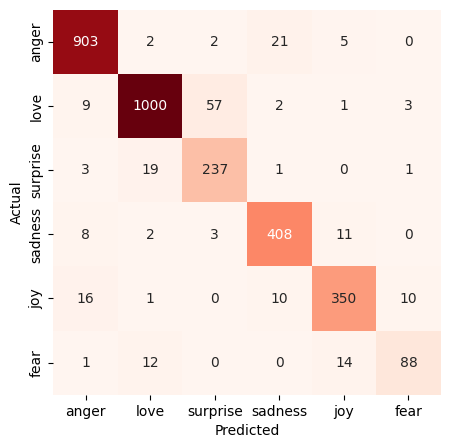

In [47]:
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, xticklabels=label2id.keys(), yticklabels=label2id.keys(), fmt='d', cbar=False, cmap='Reds')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Build Prediction Function and Store Model

In [48]:
# Test the model on a new sentence
text = 'I am super happy today. I got it done. Finally!'

# Tokenize the input text and move it to the same device as the model
input_encoded = tokenizer(text, return_tensors='pt').to(device)

In [49]:
input_encoded

{'input_ids': tensor([[ 101, 1045, 2572, 3565, 3407, 2651, 1012, 1045, 2288, 2009, 2589, 1012,
         2633,  999,  102]], device='cuda:0'), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}

In [50]:
# Disable gradient calculation during inference
with torch.no_grad():
  outputs = model(**input_encoded)

# Get the output logits
logits = outputs.logits
logits

tensor([[-1.2995,  8.4570, -0.2939, -1.8282, -1.8955, -1.5774]],
       device='cuda:0')

In [51]:
# Convert logits to the predicted class ID
pred = torch.argmax(logits, dim=1).item()
pred, id2label[pred]

(1, 'joy')

In [52]:
# Create a function for prediction
def get_prediction(text):
  input_encoded = tokenizer(text, return_tensors='pt').to(device)
  with torch.no_grad():
    outputs = model(**input_encoded)
  logits = outputs.logits
  pred = torch.argmax(logits, dim=1).item()
  return id2label[pred]

# Predict the label for the example text`
prediction = get_prediction(text)

In [53]:
prediction

'joy'

In [54]:
# Save the trained model locally
trainer.save_model('bert-base-uncased-sentiment-model')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [55]:
from google.colab import userdata

hf_token = userdata.get("HF_TOKEN")

In [ ]:
# Push the model to Hugging Face Hub
# hf_token should be defined before running this step
trainer.push_to_hub(token=hf_token)